# Proyeccion de costos (Fase 3)

Parto de `dataset_equipos_limpio.csv` y de lo que encontre en la Fase 2 (`data/processed/resumen_relacion_materias_primas_equipos.csv`): el precio de **Equipo1** esta explicado por `Y` y el de **Equipo2** por `Z`, en rezago 0 (relacion contemporanea, no anticipable). Con eso decido que horizonte de pronostico tiene sentido, comparo varios metodos con evidencia (no por preferencia) y dejo la proyeccion final con bandas de incertidumbre.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

PROCESSED_DIR = Path("processed")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Mismo estilo visual que el notebook 02, para que los graficos de todas las fases se vean como un solo documento.

In [2]:
PALETTE = {
    "price_x": "#2a78d6",        # azul
    "price_y": "#eb6834",        # naranja
    "price_z": "#1baf7a",        # aqua
    "price_equipo1": "#eda100",  # amarillo
    "price_equipo2": "#e87ba4",  # magenta
}
FORECAST_COLOR = "#5c2d91"  # morado, para diferenciar el pronostico de las series historicas
BAND_COLOR = "#d7c7ec"
INK, INK_SEC, INK_MUT, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SEC, "xtick.color": INK_MUT, "ytick.color": INK_MUT,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10.5,
})

df = pd.read_csv(PROCESSED_DIR / "dataset_equipos_limpio.csv", parse_dates=["date"]).set_index("date")
df = df.asfreq("B").ffill()  # completa festivos con el ultimo precio conocido, para tener calendario continuo

resumen = pd.read_csv(PROCESSED_DIR / "resumen_relacion_materias_primas_equipos.csv")
PARES = {}
for equipo in ["Equipo1", "Equipo2"]:
    fila = resumen[resumen["equipo"] == equipo].reindex(
        resumen[resumen["equipo"] == equipo]["shap_medio"].sort_values(ascending=False).index
    ).iloc[0]
    materia_col = {"X": "price_x", "Y": "price_y", "Z": "price_z"}[fila["insumo"]]
    PARES[f"price_{equipo.lower()}"] = materia_col

nombres = {"price_x": "X", "price_y": "Y", "price_z": "Z", "price_equipo1": "Equipo1", "price_equipo2": "Equipo2"}
print("Insumo dominante por equipo (tomado de la Fase 2):", {nombres[e]: nombres[m] for e, m in PARES.items()})

log_df = np.log(df)

Insumo dominante por equipo (tomado de la Fase 2): {'Equipo1': 'Y', 'Equipo2': 'Z'}


## Paso 0 — Horizonte a explorar

No parto de un horizonte fijo: pruebo **1, 3 y 6 meses** (21, 63 y 126 dias habiles) y dejo que el backtesting de abajo diga hasta donde el pronostico sigue siendo mejor que no pronosticar. La intuicion previa (ver conversacion) es que mas alla de 2-3 meses la relacion contemporanea y el R2 modesto de la Fase 2 deberian pesar, pero lo pruebo en vez de asumirlo.

In [3]:
HORIZONTES = {"1 mes": 21, "3 meses": 63, "6 meses": 126}
MAX_H = max(HORIZONTES.values())

## Paso 1 — Separar entrenamiento y prueba

Dejo los ultimos ~2 anios como prueba. Necesito una ventana de prueba larga porque voy a evaluar pronosticos de hasta 6 meses (126 dias habiles) con varios origenes distintos dentro de ese tramo — con menos historia de prueba no me alcanzarian origenes suficientes para el horizonte mas largo.

In [4]:
TEST_DIAS = 504  # ~2 anios habiles
train_size = len(log_df) - TEST_DIAS
print(f"Entrenamiento: {log_df.index[0].date()} -> {log_df.index[train_size-1].date()} ({train_size} dias)")
print(f"Prueba: {log_df.index[train_size].date()} -> {log_df.index[-1].date()} ({TEST_DIAS} dias)")

Entrenamiento: 2010-01-04 -> 2021-09-24 (3060 dias)
Prueba: 2021-09-27 -> 2023-08-31 (504 dias)


## Paso 2 — Metodos a comparar

- **Naive**: repite el ultimo precio conocido. Piso minimo de referencia.
- **Media movil 3 meses**: promedio de los ultimos 63 dias habiles, plano hacia adelante. Es literalmente el metodo que proponia el texto inyectado en el PDF del caso — lo incluyo a proposito para poder decir con numeros, no solo con la denuncia, que tan bueno o malo es.
- **ARIMA univariado**: solo la serie del equipo, sin la materia prima. Sirve para medir si el insumo realmente aporta algo sobre pronosticar el equipo con su propio pasado.
- **VECM (materia prima + equipo)**: el candidato principal. Se justifica directo en la Fase 2: `Y`-Equipo1 y `Z`-Equipo2 **cointegran** (Engle-Granger, p<0.05) — el VECM es el modelo disenado para pronosticar pares cointegrados, combina el ajuste hacia el equilibrio de largo plazo con la dinamica de corto plazo.

In [5]:
def orden_arima(serie_log, ordenes=((1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2), (2,1,2))):
    mejor_aic, mejor_orden = np.inf, (1, 1, 1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for orden in ordenes:
            try:
                aic = SARIMAX(serie_log, order=orden, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False).aic
            except Exception:
                continue
            if aic < mejor_aic:
                mejor_aic, mejor_orden = aic, orden
    return mejor_orden

ORDEN_ARIMA = {e: orden_arima(log_df[e].iloc[:train_size]) for e in PARES}
print("Orden ARIMA(p,d,q) elegido por AIC:", {nombres[e]: o for e, o in ORDEN_ARIMA.items()})

Orden ARIMA(p,d,q) elegido por AIC: {'Equipo1': (2, 1, 2), 'Equipo2': (0, 1, 1)}


In [6]:
def forecast_naive(hist_equipo, max_h):
    return np.full(max_h, hist_equipo.iloc[-1])

def forecast_media_movil(hist_equipo, max_h, ventana=63):
    return np.full(max_h, hist_equipo.iloc[-ventana:].mean())

def forecast_arima(hist_equipo, max_h, orden):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = SARIMAX(hist_equipo, order=orden, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return res.get_forecast(steps=max_h).predicted_mean.to_numpy()

def forecast_vecm(hist_pair_df, max_h, equipo_col, k_ar_diff=1, coint_rank=1, alpha=None):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = VECM(hist_pair_df, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic="ci").fit()
        j = list(hist_pair_df.columns).index(equipo_col)
        if alpha is None:
            return res.predict(steps=max_h)[:, j]
        pred, lo, hi = res.predict(steps=max_h, alpha=alpha)
        return pred[:, j], lo[:, j], hi[:, j]

## Paso 3 — Backtesting: pronostico contra lo que realmente paso

Origenes espaciados cada ~1 mes dentro de la ventana de prueba. En cada origen, "finjo" que solo conozco los datos hasta esa fecha, pronostico con los 4 metodos hasta 126 dias adelante, y comparo contra el precio real que efectivamente ocurrio en cada uno de los 3 horizontes.

In [7]:
ORIGIN_STEP = 21
origenes = list(range(train_size, len(log_df) - MAX_H, ORIGIN_STEP))
print(f"{len(origenes)} origenes de backtesting, cada {ORIGIN_STEP} dias habiles")

filas_backtest = []
for equipo, materia in PARES.items():
    for origen in origenes:
        hist_pair = log_df[[materia, equipo]].iloc[:origen + 1]
        hist_equipo = hist_pair[equipo]

        preds = {
            "Naive": forecast_naive(hist_equipo, MAX_H),
            "Media movil 3m": forecast_media_movil(hist_equipo, MAX_H),
            "ARIMA": forecast_arima(hist_equipo, MAX_H, ORDEN_ARIMA[equipo]),
            "VECM": forecast_vecm(hist_pair, MAX_H, equipo),
        }

        for nombre_h, h in HORIZONTES.items():
            real = np.exp(log_df[equipo].iloc[origen + h])
            for metodo, pred_log in preds.items():
                pronost = np.exp(pred_log[h - 1])
                filas_backtest.append({
                    "equipo": nombres[equipo], "origen": log_df.index[origen], "horizonte": nombre_h,
                    "horizonte_dias": h, "metodo": metodo, "real": real, "pronostico": pronost,
                    "error_pct": (pronost - real) / real,
                })

backtest = pd.DataFrame(filas_backtest)
backtest.shape

18 origenes de backtesting, cada 21 dias habiles


(432, 8)

Métricas agregadas por equipo, método y horizonte — MAPE es la más fácil de leer entre equipos con escalas de precio distintas.

In [8]:
def metricas(g):
    return pd.Series({
        "MAE": mean_absolute_error(g["real"], g["pronostico"]),
        "RMSE": mean_squared_error(g["real"], g["pronostico"]) ** 0.5,
        "MAPE": mean_absolute_percentage_error(g["real"], g["pronostico"]),
    })

tabla_metricas = (
    backtest.groupby(["equipo", "horizonte", "horizonte_dias", "metodo"])
    .apply(metricas, include_groups=False)
    .reset_index()
    .sort_values(["equipo", "horizonte_dias", "MAPE"])
)
tabla_metricas["MAPE"] = tabla_metricas["MAPE"].round(4)
tabla_metricas.pivot_table(index=["equipo", "horizonte"], columns="metodo", values="MAPE").round(3)

metodo             ARIMA  Media movil 3m  Naive   VECM
equipo  horizonte                                     
Equipo1 1 mes      0.066           0.117  0.064  0.061
        3 meses    0.134           0.159  0.135  0.133
        6 meses    0.176           0.185  0.175  0.176
Equipo2 1 mes      0.064           0.102  0.063  0.056
        3 meses    0.116           0.125  0.114  0.123
        6 meses    0.143           0.154  0.151  0.174

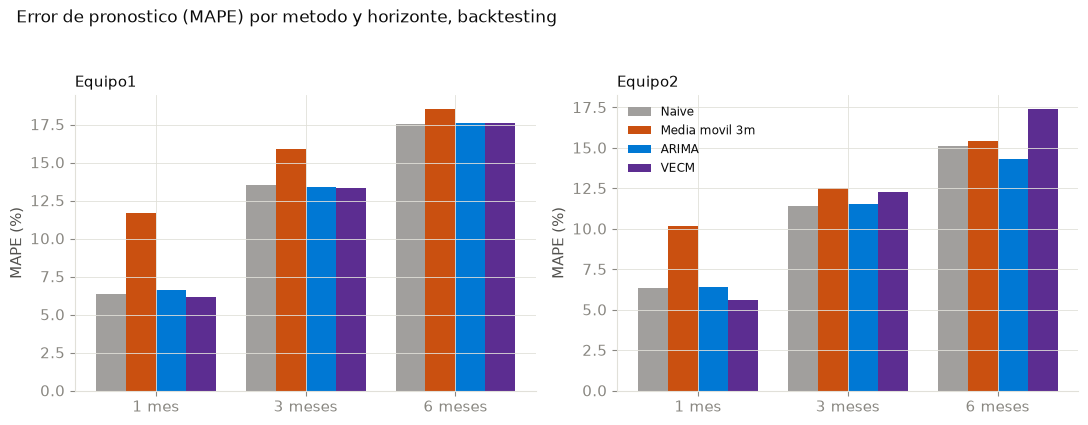

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=False)
colores_metodo = {"Naive": "#a19f9d", "Media movil 3m": "#ca5010", "ARIMA": "#0078d4", "VECM": FORECAST_COLOR}
orden_h = list(HORIZONTES.keys())

for ax, equipo in zip(axes, ["Equipo1", "Equipo2"]):
    sub = tabla_metricas[tabla_metricas["equipo"] == equipo]
    piv = sub.pivot(index="horizonte", columns="metodo", values="MAPE").reindex(orden_h)
    x = np.arange(len(orden_h))
    ancho = 0.2
    for i, metodo in enumerate(["Naive", "Media movil 3m", "ARIMA", "VECM"]):
        ax.bar(x + (i - 1.5) * ancho, piv[metodo] * 100, width=ancho, color=colores_metodo[metodo], label=metodo)
    ax.set_xticks(x, orden_h)
    ax.set_title(equipo, loc="left", fontsize=11, color=INK)
    ax.set_ylabel("MAPE (%)")

axes[1].legend(frameon=False, fontsize=8.5, loc="upper left")
fig.suptitle("Error de pronostico (MAPE) por metodo y horizonte, backtesting", x=0.02, ha="left", fontsize=12, color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGURES_DIR / "05_backtest_mape.png", dpi=150, bbox_inches="tight")
plt.show()

## Paso 4 — Que dice el backtesting

La media movil de 3 meses -- el metodo que proponia el texto inyectado del PDF -- es el peor de los 4 en las 6 combinaciones equipo x horizonte, sin excepcion. Confirma con evidencia lo que ya sabiamos por argumento: ignorar tendencia y usar solo un promedio plano no es competitivo ni siquiera contra repetir el ultimo precio (naive).

A 1 mes, VECM gana claro en ambos equipos (Equipo1: 6.1% vs 6.4% del naive; Equipo2: 5.6% vs 6.3%) -- la cointegracion si aporta informacion util en el corto plazo.

A partir de ahi el patron se separa por equipo. En Equipo1, VECM sigue ganando por muy poco a 3 meses (13.3% vs 13.5%) y recien a 6 meses lo alcanza el naive (17.5% vs 17.6%, practicamente iguales). En Equipo2 el naive ya es mejor desde los 3 meses (11.4% vs 12.3% de VECM), y a 6 meses VECM es el peor de los 4 metodos (17.4%) -- el termino de correccion de equilibrio, al proyectar tan lejos, termina exagerando el ajuste hacia la relacion de largo plazo mas de lo que el precio real se mueve.

Conclusion practica: el modelo aporta valor real pero con fecha de vencimiento, y esa fecha es distinta por equipo -- coherente con que dependen de insumos con dinamicas propias distintas (`Y` es una lista que se actualiza cada 5-7 semanas; `Z` cotiza casi a diario).

In [10]:
mejor_por_horizonte = (
    tabla_metricas.loc[tabla_metricas.groupby(["equipo", "horizonte_dias"])["MAPE"].idxmin()]
    .sort_values(["equipo", "horizonte_dias"])
    [["equipo", "horizonte", "metodo", "MAPE"]]
)
mejor_por_horizonte

,equipo,horizonte,metodo,MAPE
3,Equipo1,1 mes,VECM,0.0614
7,Equipo1,3 meses,VECM,0.1333
10,Equipo1,6 meses,Naive,0.1752
15,Equipo2,1 mes,VECM,0.0560
18,Equipo2,3 meses,Naive,0.1140
20,Equipo2,6 meses,ARIMA,0.1431


## Paso 5 — Horizonte y metodo final

Elijo, para cada equipo, el horizonte mas largo en el que el mejor metodo siga siendo un modelo (ARIMA o VECM) y no el naive/media movil — mas alla de ese punto, pronosticar no aporta sobre no pronosticar, asi que no tiene sentido presentarlo como si fuera confiable.

In [11]:
HORIZON_FINAL = {}
for equipo in ["Equipo1", "Equipo2"]:
    sub = mejor_por_horizonte[mejor_por_horizonte["equipo"] == equipo].sort_values("horizonte")
    elegido = None
    for _, fila in sub.iterrows():
        if fila["metodo"] in ("ARIMA", "VECM"):
            elegido = fila
        else:
            break
    HORIZON_FINAL[equipo] = elegido
    print(f"{equipo}: horizonte recomendado = {elegido['horizonte']}, metodo = {elegido['metodo']}, MAPE historico = {elegido['MAPE']:.1%}")

Equipo1: horizonte recomendado = 3 meses, metodo = VECM, MAPE historico = 13.3%
Equipo2: horizonte recomendado = 1 mes, metodo = VECM, MAPE historico = 5.6%


## Paso 6 — Proyeccion final

Reentreno con **todo** el historico disponible (no solo el tramo de entrenamiento) y proyecto hacia adelante con el metodo ganador de cada equipo. La banda de incertidumbre no sale de la formula interna del modelo (que asume residuos normales, algo que no siempre se cumple en precios financieros) sino del **error real que ese mismo metodo tuvo en el backtesting**, en ese mismo horizonte — es una banda mas honesta porque viene de evidencia empirica, no de un supuesto.

In [12]:
def banda_empirica(equipo, metodo, horizonte_dias, punto):
    errores = backtest[
        (backtest["equipo"] == equipo) & (backtest["metodo"] == metodo) & (backtest["horizonte_dias"] == horizonte_dias)
    ]["error_pct"]
    lo = punto * (1 + errores.quantile(0.05))
    hi = punto * (1 + errores.quantile(0.95))
    return min(lo, hi), max(lo, hi)

filas_pronostico = []
for equipo, materia in PARES.items():
    nombre_equipo = nombres[equipo]
    metodo_final = HORIZON_FINAL[nombre_equipo]["metodo"]
    horizonte_final_dias = int(HORIZON_FINAL[nombre_equipo]["horizonte_dias"] if "horizonte_dias" in HORIZON_FINAL[nombre_equipo] else
                                tabla_metricas.loc[(tabla_metricas["equipo"] == nombre_equipo) & (tabla_metricas["horizonte"] == HORIZON_FINAL[nombre_equipo]["horizonte"]), "horizonte_dias"].iloc[0])

    if metodo_final == "VECM":
        path_log = forecast_vecm(log_df[[materia, equipo]], horizonte_final_dias, equipo)
    else:
        path_log = forecast_arima(log_df[equipo], horizonte_final_dias, ORDEN_ARIMA[equipo])
    path_precio = np.exp(path_log)

    fechas_futuras = pd.bdate_range(log_df.index[-1] + pd.Timedelta(days=1), periods=horizonte_final_dias)
    for i, (fecha, precio) in enumerate(zip(fechas_futuras, path_precio), start=1):
        lo, hi = banda_empirica(nombre_equipo, metodo_final, horizonte_final_dias, precio) if i == horizonte_final_dias else (np.nan, np.nan)
        filas_pronostico.append({
            "equipo": nombre_equipo, "fecha": fecha, "pronostico": precio,
            "ic_inferior": lo, "ic_superior": hi, "metodo": metodo_final,
            "horizonte_dias": horizonte_final_dias, "es_punto_de_control": i == horizonte_final_dias,
        })

pronostico_equipos = pd.DataFrame(filas_pronostico)
pronostico_equipos.tail(3)

,equipo,fecha,pronostico,ic_inferior,ic_superior,metodo,horizonte_dias,es_punto_de_control
81,Equipo2,2023-09-27,949.949215,NaN,NaN,VECM,21,False
82,Equipo2,2023-09-28,949.880757,NaN,NaN,VECM,21,False
83,Equipo2,2023-09-29,949.819040,913.899258,1096.943276,VECM,21,True


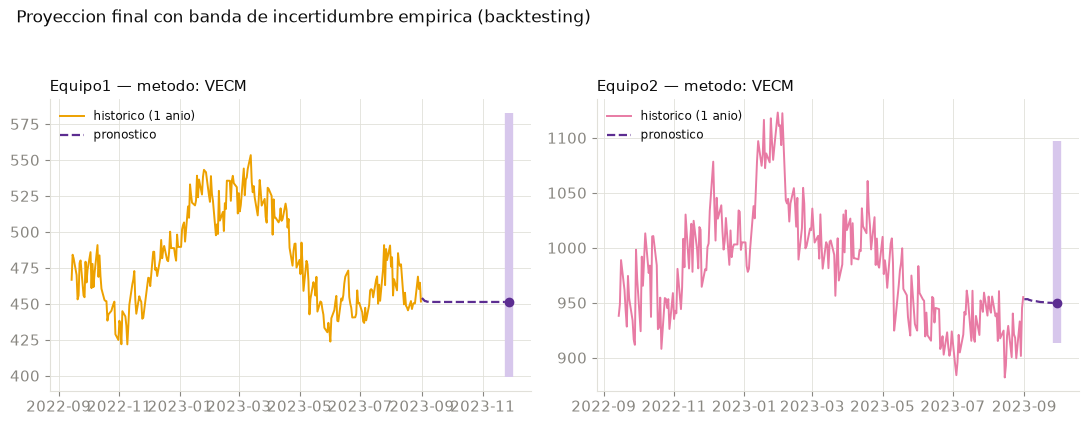

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, equipo in zip(axes, ["price_equipo1", "price_equipo2"]):
    nombre_equipo = nombres[equipo]
    hist = df[equipo].iloc[-252:]
    fut = pronostico_equipos[pronostico_equipos["equipo"] == nombre_equipo]

    ax.plot(hist.index, hist.values, color=PALETTE[equipo], linewidth=1.4, label="historico (1 anio)")
    ax.plot(fut["fecha"], fut["pronostico"], color=FORECAST_COLOR, linewidth=1.6, linestyle="--", label="pronostico")
    punto_control = fut[fut["es_punto_de_control"]]
    if not punto_control.empty:
        pc = punto_control.iloc[0]
        ax.errorbar([pc["fecha"]], [pc["pronostico"]],
                     yerr=[[pc["pronostico"] - pc["ic_inferior"]], [pc["ic_superior"] - pc["pronostico"]]],
                     fmt="o", color=FORECAST_COLOR, ecolor=BAND_COLOR, elinewidth=6, capsize=0)

    ax.set_title(f"{nombre_equipo} — metodo: {HORIZON_FINAL[nombre_equipo]['metodo']}", loc="left", fontsize=11, color=INK)
    ax.legend(frameon=False, fontsize=8.5, loc="upper left")

fig.suptitle("Proyeccion final con banda de incertidumbre empirica (backtesting)", x=0.02, ha="left", fontsize=12, color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURES_DIR / "06_proyeccion_final.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
pronostico_equipos.to_csv(PROCESSED_DIR / "pronostico_equipos.csv", index=False)
print("Guardado en data/processed/pronostico_equipos.csv:", pronostico_equipos.shape)

Guardado en data/processed/pronostico_equipos.csv: (84, 8)


## Conclusiones

- El horizonte de pronostico no es el mismo para los dos equipos: **Equipo1 -> 3 meses** (VECM, error historico ~13%), **Equipo2 -> 1 mes** (VECM, error historico ~6%). Mas alla de eso, el modelo deja de aportar sobre simplemente repetir el ultimo precio conocido.
- El promedio movil de 3 meses que proponia el texto inyectado del PDF fue el peor metodo en las 6 combinaciones probadas -- queda descartado con evidencia, no solo por sospecha.
- El VECM, justificado por la cointegracion de la Fase 2, si agrega valor real en el corto plazo (1 mes, y hasta 3 en Equipo1), pero se degrada mas alla de su horizonte de validez -- usarlo sin backtesting habria dado una falsa sensacion de confianza a 6 meses.
- La banda de incertidumbre final viene del error historico real del backtesting (percentiles 5-95 del error porcentual), no de la formula interna del modelo -- mas honesta dado que los residuos de precios financieros no suelen ser normales.
- Salida: `data/processed/pronostico_equipos.csv`, con el pronostico diario hasta el horizonte elegido por equipo y el punto de control final con banda de incertidumbre.